In [2]:
from google.colab import files

uploaded = files.upload()

Saving placement_predict_50k Dataset.csv to placement_predict_50k Dataset.csv


In [5]:
import pandas as pd

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print(df.head())

   StudentID  Gender       City CollegeTier Stream Specialisation Hostel  \
0          1    Male  Ahmedabad       Tier2    ECE     Networking     No   
1          2  Female     Mumbai       Tier2    ECE    DataScience    Yes   
2          3    Male    Kolkata       Tier2     IT    DataScience    Yes   
3          4    Male     Jaipur       Tier1     CS             AI     No   
4          5    Male       Pune       Tier2     IT    DataScience    Yes   

  HistoryOfBacklogs  SGPA_Sem1  SGPA_Sem2  ...  Publications  \
0                No       6.02       6.54  ...             0   
1               Yes       5.84       5.12  ...             0   
2                No       4.91       5.29  ...             0   
3                No       7.67       8.03  ...             0   
4                No       8.14       8.97  ...             1   

   AptitudeTestScore  SoftSkillsRating  CodingTestScore  MockInterviewScore  \
0               66.7               2.2             49.4                47.8   


In [6]:
print(df.columns)

Index(['StudentID', 'Gender', 'City', 'CollegeTier', 'Stream',
       'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'SGPA_Sem1',
       'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6',
       'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships',
       'Projects', 'Workshops', 'Certifications', 'Publications',
       'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore',
       'MockInterviewScore', 'ExtraCurricular', 'CGPA_Tier', 'PlacementStatus',
       'IsAnomaly', 'Salary Package'],
      dtype='object')


In [9]:
FEATURES = [
    "SGPA_Sem1",
    "SGPA_Sem2",
    "SGPA_Sem3",
    "SGPA_Sem4",
    "SGPA_Sem5",
    "SGPA_Sem6",
    "SGPA_Sem7",
    "SGPA_Sem8",
    "CGPA",
    "AttendancePercent",
    "Internships",
    "Projects",
    "Workshops",
    "Certifications",
    "Publications",
    "AptitudeTestScore",
    "SoftSkillsRating",
    "CodingTestScore",
    "MockInterviewScore",
    "ExtraCurricular"
]

TARGET = "Salary Package"

data = df[FEATURES + [TARGET]].copy()

print(data.head())

   SGPA_Sem1  SGPA_Sem2  SGPA_Sem3  SGPA_Sem4  SGPA_Sem5  SGPA_Sem6  \
0       6.02       6.54       6.52       6.00       6.47       5.91   
1       5.84       5.12       5.34       5.18       5.03       4.93   
2       4.91       5.29       5.49       5.73       5.33       5.88   
3       7.67       8.03       8.08       7.64       6.86       7.10   
4       8.14       8.97       8.36       8.55       8.55       8.38   

   SGPA_Sem7  SGPA_Sem8  CGPA  AttendancePercent  ...  Projects  Workshops  \
0       6.49       5.50  6.29               73.3  ...         2        NaN   
1       5.40       5.13  5.23               54.5  ...         1        0.0   
2       5.82       5.67  5.52               77.6  ...         3        1.0   
3       7.56       7.39  7.51               68.8  ...         2        1.0   
4       9.10       8.86  8.65               95.8  ...         3        NaN   

   Certifications  Publications  AptitudeTestScore  SoftSkillsRating  \
0               2             0 

In [10]:
data[FEATURES] = data[FEATURES].fillna(data[FEATURES].median())

In [11]:
X = data[FEATURES].values

y = data[TARGET].values.reshape(-1, 1)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (50000, 20)
y shape: (50000, 1)


In [12]:
from sklearn.model_selection import train_test_split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (40000, 20)
X_test: (10000, 20)
y_train: (40000, 1)
y_test: (10000, 1)


In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)

X_test_s = scaler.transform(X_test)

print("Scaled training data:", X_train_s.shape)
print("Scaled testing data:", X_test_s.shape)

Scaled training data: (40000, 20)
Scaled testing data: (10000, 20)


In [16]:
import numpy as np

# Get number of training samples and features
n_samples, n_features = X_train_s.shape

# Add bias (intercept) column to training data
X_train_b = np.hstack([
    np.ones((n_samples, 1)),
    X_train_s
])

# Add bias (intercept) column to testing data
X_test_b = np.hstack([
    np.ones((X_test_s.shape[0], 1)),
    X_test_s
])

print("X_train_b shape:", X_train_b.shape)
print("X_test_b shape:", X_test_b.shape)

X_train_b shape: (40000, 21)
X_test_b shape: (10000, 21)


In [17]:
def compute_mse(X, y, theta):
    # Calculate predictions
    preds = X @ theta

    # Calculate errors
    errors = preds - y

    # Return Mean Squared Error
    return np.mean(errors ** 2)

In [18]:
def batch_gradient_descent(X, y, lr=0.01, n_epochs=1000):

    # Number of samples and features
    m, n = X.shape

    # Initialize theta with zeros
    theta = np.zeros((n, 1))

    # Store MSE for every epoch
    loss_history = []

    # Repeat for given number of epochs
    for epoch in range(n_epochs):

        # Calculate predictions
        preds = X @ theta

        # Calculate errors
        errors = preds - y

        # Calculate gradient
        gradient = (2 / m) * (X.T @ errors)

        # Update theta
        theta -= lr * gradient

        # Store current MSE
        loss_history.append(compute_mse(X, y, theta))

    return theta, loss_history

In [19]:
theta_gd, loss_history_gd = batch_gradient_descent(
    X_train_b,
    y_train,
    lr=0.01,
    n_epochs=1000
)

print("Theta shape:", theta_gd.shape)
print("Final training MSE:", loss_history_gd[-1])

Theta shape: (21, 1)
Final training MSE: 15.457658693308709


In [23]:
rmse_gd = np.sqrt(
    compute_mse(X_test_b, y_test, theta_gd)
)

print("Batch GD Test RMSE:", rmse_gd)

Batch GD Test RMSE: 3.960541716892869


In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

sk_model = LinearRegression()

# Train the model
sk_model.fit(X_train_s, y_train)

# Make predictions
y_pred_sk = sk_model.predict(X_test_s)

# Calculate RMSE
rmse_sklearn = np.sqrt(
    mean_squared_error(y_test, y_pred_sk)
)

print("Sklearn Linear Regression Test RMSE:", rmse_sklearn)

Sklearn Linear Regression Test RMSE: 3.9604015000376567


In [25]:
def mini_batch_gradient_descent(
    X,
    y,
    lr=0.01,
    n_epochs=1000,
    batch_size=256,
    seed=42
):

    m, n = X.shape

    # Initialize theta
    theta = np.zeros((n, 1))

    # Store loss
    loss_history = []

    # Random number generator
    rng = np.random.default_rng(seed)

    for epoch in range(n_epochs):

        # Shuffle the data
        indices = rng.permutation(m)

        X_shuffled = X[indices]
        y_shuffled = y[indices]

        # Go through mini-batches
        for start in range(0, m, batch_size):

            end = start + batch_size

            X_batch = X_shuffled[start:end]
            y_batch = y_shuffled[start:end]

            # Prediction
            preds = X_batch @ theta

            # Error
            errors = preds - y_batch

            # Gradient
            gradient = (2 / X_batch.shape[0]) * (
                X_batch.T @ errors
            )

            # Update theta
            theta -= lr * gradient

        # Store MSE after each epoch
        loss_history.append(
            compute_mse(X, y, theta)
        )

    return theta, loss_history

In [26]:
theta_mb, loss_history_mb = mini_batch_gradient_descent(
    X_train_b,
    y_train,
    lr=0.01,
    n_epochs=1000,
    batch_size=256
)

print("Theta shape:", theta_mb.shape)
print("Final training MSE:", loss_history_mb[-1])

Theta shape: (21, 1)
Final training MSE: 15.463336520038382


In [28]:
rmse_mb = np.sqrt(
    compute_mse(
        X_test_b,
        y_test,
        theta_mb
    )
)

print("Mini-Batch GD Test RMSE:", rmse_mb)

Mini-Batch GD Test RMSE: 3.9608702435873453


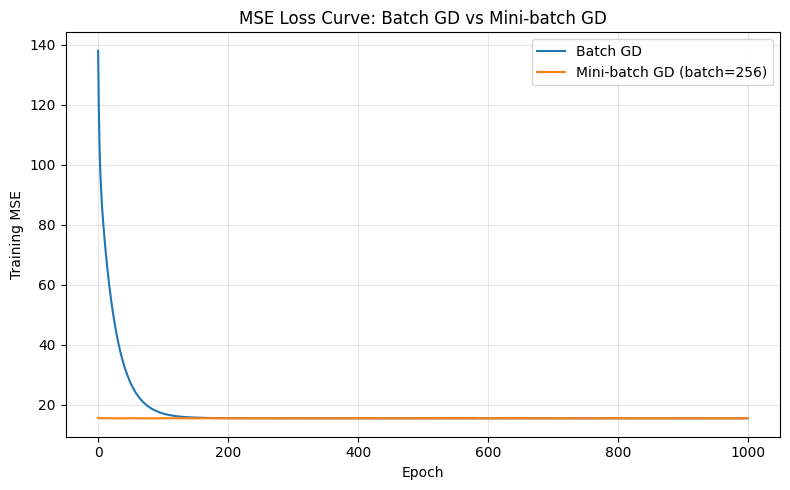

Saved loss curve to loss_curve.png


In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    loss_history_gd,
    label="Batch GD"
)

plt.plot(
    loss_history_mb,
    label="Mini-batch GD (batch=256)"
)

plt.xlabel("Epoch")
plt.ylabel("Training MSE")

plt.title("MSE Loss Curve: Batch GD vs Mini-batch GD")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("loss_curve.png", dpi=150)

plt.show()

print("Saved loss curve to loss_curve.png")

In [31]:
print("\n=== RMSE Comparison ===")

print(f"{'Method':<20}{'Test RMSE':>12}")

print(f"{'Batch GD':<20}{rmse_gd:>12.4f}")

print(f"{'Mini-batch GD':<20}{rmse_mb:>12.4f}")

print(f"{'sklearn LinearReg':<20}{rmse_sklearn:>12.4f}")


=== RMSE Comparison ===
Method                 Test RMSE
Batch GD                  3.9605
Mini-batch GD             3.9609
sklearn LinearReg         3.9604
